<a href="https://colab.research.google.com/github/Pedroct06/Estudos-NN/blob/main/RockPaperScissor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Modelo de rede neural para classificação do jogo Pedra, Papel e Tesoura, seguindo a aula do youtube https://www.youtube.com/watch?v=44U8jJxaNp8

#Installation

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import tensorflow_datasets as tfds
from tensorflow import keras
tfds.disable_progress_bar

<function tensorflow_datasets.core.utils.tqdm_utils.disable_progress_bar()>

##Find Datasets

In [ ]:
tfds.list_builders()

['abstract_reasoning',
 'accentdb',
 'aeslc',
 'aflw2k3d',
 'ag_news_subset',
 'ai2_arc',
 'ai2_arc_with_ir',
 'ai2dcaption',
 'aloha_mobile',
 'amazon_us_reviews',
 'anli',
 'answer_equivalence',
 'arc',
 'asimov_dilemmas_auto_val',
 'asimov_dilemmas_scifi_train',
 'asimov_dilemmas_scifi_val',
 'asimov_injury_val',
 'asimov_multimodal_auto_val',
 'asimov_multimodal_manual_val',
 'asqa',
 'asset',
 'assin2',
 'asu_table_top_converted_externally_to_rlds',
 'austin_buds_dataset_converted_externally_to_rlds',
 'austin_sailor_dataset_converted_externally_to_rlds',
 'austin_sirius_dataset_converted_externally_to_rlds',
 'bair_robot_pushing_small',
 'bc_z',
 'bccd',
 'beans',
 'bee_dataset',
 'beir',
 'berkeley_autolab_ur5',
 'berkeley_cable_routing',
 'berkeley_fanuc_manipulation',
 'berkeley_gnm_cory_hall',
 'berkeley_gnm_recon',
 'berkeley_gnm_sac_son',
 'berkeley_mvp_converted_externally_to_rlds',
 'berkeley_rpt_converted_externally_to_rlds',
 'big_patent',
 'bigearthnet',
 'billsum',
 '

##Get information on the Data

In [ ]:
builder = tfds.builder('rock_paper_scissors')
info = builder.info
info

tfds.core.DatasetInfo(
    name='rock_paper_scissors',
    full_name='rock_paper_scissors/3.0.0',
    description="""
    Images of hands playing rock, paper, scissor game.
    """,
    homepage='http://laurencemoroney.com/rock-paper-scissors-dataset',
    data_dir='/root/tensorflow_datasets/rock_paper_scissors/3.0.0',
    file_format=tfrecord,
    download_size=Unknown size,
    dataset_size=Unknown size,
    features=FeaturesDict({
        'image': Image(shape=(300, 300, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=3),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
    },
    citation="""@ONLINE {rps,
    author = "Laurence Moroney",
    title = "Rock, Paper, Scissors Dataset",
    month = "feb",
    year = "2019",
    url = "http://laurencemoroney.com/rock-paper-scissors-dataset"
    }""",
)

##Prepare Rock, Paper, Scissors Data

In [ ]:
ds_train = tfds.load(name= "rock_paper_scissors", split = "train")
ds_test = tfds.load(name="rock_paper_scissors", split = "test")

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.XOOFT8_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.XOOFT8_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.


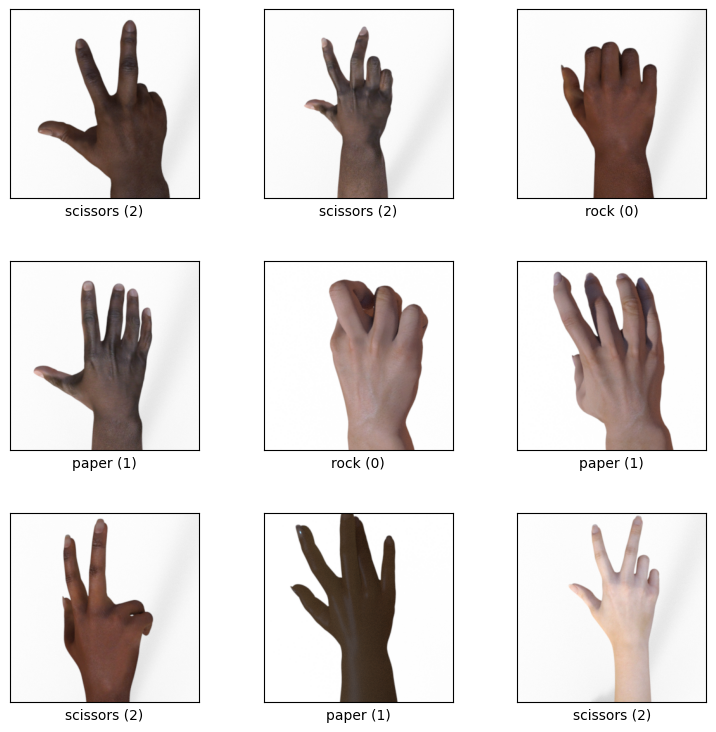

In [ ]:
fig = tfds.show_examples(ds_train, info)

## Additional Data Prep

In [ ]:
train_images = np.array([example['image'].numpy()[:,:,0] for example in ds_train])
train_labels = np.array([example['label'].numpy() for example in ds_train])

test_images = np.array([example['image'].numpy()[:,:,0] for example in ds_test])
test_labels = np.array([example['label'].numpy() for example in ds_test])

In [ ]:
train_images = train_images.reshape(2520,300,300,1)
test_images = test_images.reshape(372,300,300,1)

train_images = train_images.astype('float32')
test_images = test_images.astype('float32')

train_images /= 255
test_images /= 255

## Train a network

In [ ]:
modelo = keras.Sequential([
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation = "relu"),
    keras.layers.Dense(256, activation= 'relu'),
    keras.layers.Dense(3, activation='softmax')
])

modelo.compile(optimizer = 'adam',
               loss = keras.losses.SparseCategoricalCrossentropy(),
               metrics = ['accuracy'])
modelo.fit(train_images, train_labels, epochs = 10, batch_size=32)

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.4056 - loss: 25.0246
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6516 - loss: 1.1886
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7075 - loss: 0.9619
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7976 - loss: 0.5663
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8766 - loss: 0.3229
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8885 - loss: 0.3067
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8492 - loss: 0.4955
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7679 - loss: 0.6892
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8798 - loss: 0.3257
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9381 - loss: 0.1744


In [ ]:
modelo.evaluate(test_images, test_labels)

12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.6022 - loss: 1.9892


[1.9891841411590576, 0.602150559425354]

##Train Neural Network convolutional approach

In [ ]:
model = keras.Sequential([
    keras.layers.Conv2D(64, 3, activation = "relu", input_shape = (300,300,1)),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    keras.layers.Conv2D(32, 3, activation="relu"),
    keras.layers.MaxPooling2D(pool_size=(2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(3, activation = "softmax")
])

model.compile(optimizer = 'adam',
               loss = keras.losses.SparseCategoricalCrossentropy(),
               metrics = ['accuracy'])
model.fit(train_images, train_labels, epochs = 10, batch_size=32)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 11s 109ms/step - accuracy: 0.7631 - loss: 0.7939
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.9917 - loss: 0.0342
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.9992 - loss: 0.0049
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.9980 - loss: 0.0084
Epoch 5/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 0.9996 - loss: 0.0033
Epoch 6/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 1.0000 - loss: 4.2133e-04
Epoch 7/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 1.0000 - loss: 2.1932e-04
Epoch 8/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 1.0000 - loss: 1.4717e-04
Epoch 9/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - accuracy: 1.0000 - loss: 9.9239e-05
Epoch 10/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 95ms/step - accuracy: 1.0000 - loss: 8.2283e-05


In [ ]:
loss, accuracy = model.evaluate(test_images, test_labels)
print(loss, accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.6720 - loss: 1.4955
1.4954912662506104 0.6720430254936218


##Better Convolutional Network

In [ ]:
model = keras.Sequential([
    keras.layers.Conv2D(32, 3, activation = "relu", input_shape = (300,300,1)),
    keras.layers.MaxPooling2D(pool_size=(2,2)),

    keras.layers.Conv2D(64, 3, activation="relu"),
    keras.layers.MaxPooling2D(pool_size=(2,2)),

    keras.layers.Conv2D(128,3,activation="relu"),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Conv2D(128,3,activation="relu"),
    keras.layers.MaxPooling2D(2,2),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation="relu"),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(64, activation="relu"),
    keras.layers.Dense(3, activation = "softmax")
])

model.compile(optimizer = 'adam',
               loss = keras.losses.SparseCategoricalCrossentropy(),
               metrics = ['accuracy'])
model.fit(train_images, train_labels, epochs = 10, batch_size=32, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 150ms/step - accuracy: 0.5303 - loss: 0.8866 - val_accuracy: 0.9306 - val_loss: 0.2946
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.9276 - loss: 0.2098 - val_accuracy: 0.9940 - val_loss: 0.0506
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.9727 - loss: 0.0770 - val_accuracy: 0.9980 - val_loss: 0.0101
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 105ms/step - accuracy: 0.9841 - loss: 0.0405 - val_accuracy: 0.9960 - val_loss: 0.0047
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 103ms/step - accuracy: 0.9931 - loss: 0.0188 - val_accuracy: 1.0000 - val_loss: 4.2755e-04
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 104ms/step - accuracy: 0.9980 - loss: 0.0070 - val_accuracy: 1.0000 - val_loss: 2.0874e-04
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 103ms/step - accuracy: 0.9950 - loss: 0.0157 - val_accuracy: 1.0000 - val_loss: 1.9198e-04
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 102ms/step - accuracy: 0.9995 - loss: 0.0043 - val

In [ ]:
model.evaluate(test_images, test_labels)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8172 - loss: 0.8458


[0.8457744121551514, 0.8172042965888977]